In [19]:
import os
import sys
import glob
import pickle
import netCDF4 as nc
import wrf

import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Circle
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib import rc
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature, BORDERS, ShapelyFeature, OCEAN, LAND
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.shapereader as shpreader
from shapely.geometry.polygon import Polygon
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle

import dill
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units
import cmasher as cmr
import pickle

In [7]:
path_figs = "/g/data/up6/ai2733/Gusts_downdrafts/figures/Figures/"
# Paths
path_arrays = "/g/data/up6/ai2733/Thermals_comparison/results/wrf_arrays/"
#path_arrays = "/results/wrf_arrays/"

path_results = "/g/data/up6/ai2733/Thermals_comparison/results/tracking_results/"
#path_results = "/results/tracking_results/"


In [17]:
name_cases = {"CASE1": "Event 1", 
             "CASE2_new": "Event 2",
             "CASE3_new": "Event 3"}

init_t_all_cases = {"CASE1": "2015-12-16 07:00",
                  "CASE2_new": "2009-01-20 04:30",
                  "CASE3_new": "2017-02-17 07:30"}

min_t_all_cases = {"CASE1": 420,
                  "CASE2_new": 270,
                  "CASE3_new": 450}

In [9]:
def get_dirs(case, downdrafts):
    subdir = ""
    
    """
    Returns paths and file lists for d03 thermal tracking cases.

    Parameters:
        case (str): Case name, e.g., "CASE1" or "CASE2_new"
        downdrafts (bool): True for descending thermals, False for ascending thermals

    Returns:
        path_track (str): Base folder of tracking data
        path_grid (str): Folder where grids are saved
        dd_all (list): Sorted list of npy files for each thermal
        index_all (list): Index list corresponding to dd_all
        dd_all_entr (list): Sorted list of net entrainment files
    """

    # Determine folder prefix
    prefix  = "thermal_tracking" if downdrafts else "uw_thermal_tracking"
    prefix2 = "descending_thermals" if downdrafts else "ascending_thermals"

    # Handle CASE1 vs others
    base_case = case.lower() if case == "CASE1" else case.split("_new")[0].lower()

    # Paths
    path_track = f"/g/data/up6/ai2733/Thermals_comparison/thermal_tracking_code/{prefix2}/{prefix}_{base_case}_cropped/thermals_all/"
    path_grid  = f"/g/data/w28/ai2733/outputs_{case}_budgets/grid_tracking_cropped_new/{subdir}"

    # File patterns
    file_type = "downdraft_*" if downdrafts else "thermal_*"
    dd_all      = sorted(glob.glob(f"{path_track}/{file_type}/{file_type}_data.npy"))
    dd_all_entr = sorted(glob.glob(f"{path_track}/{file_type}/{file_type}_net_entr_term.npy"))

    index_all = list(range(len(dd_all)))

    return path_track, path_grid, dd_all, index_all, dd_all_entr

In [15]:
def get_thermals(case, downdraft, idx_time):
    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    Function to get thermals at certain time
    """""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""""
    
    key = f"{case}_{dom}_{'dd' if downdraft else 'ud'}"
    # Extract data
    (
                    x_centre, y_centre, z_centre,wmax_c, W_c, time_c, R_c, z_centre_c,mass_c, path_case, N_t, t_range, R_mean, W_mean, R_std, R_10, R_90, W_std, W_10, W_90,
        acc_mean, Fres_mean, Fnh_mean, buoy_mean, acc_10, acc_90,
        Fres_10, Fres_90, Fnh_10, Fnh_90, buoy_10, buoy_90,
        t_range2, net_entr_term_mean, net_entr_term_std,
        Z, R_avg, W_avg, net_entr_avg, Z2, net_entr_l, net_entr_r,
        acc_avg, Fnh_avg, Fres_avg, buoy_avg, Fentr_avg,
        ix_left, ix_right, bins_x, weights_x,
        iz_up, iz_low, bins_z, weights_z,
        acc_c, Fres_c, buoy_c, fnh_c, fmix_c, r_c, r_c_mean, r_c_std,
        acc_c_mean, Fres_c_mean, buoy_c_mean, fnh_c_mean, fmix_c_mean,
        acc_c_std, Fres_c_std, buoy_c_std, fnh_c_std, fmix_c_std,
        N_avg, lifetime_avg, wmax_avg, massflux_avg,
        x_new, y_new, z_new, w_dev_grossmean, u_dev_grossmean, v_dev_grossmean,
                    rh_grossmean, qvapor_grossmean, qrain_grossmean, qcloud_grossmean, qicesnow_grossmean, qghail_grossmean, buoy_mean_t, detrainment_grossmean, entrainment_grossmean, latheat_grossmean, qghail_c, qcloud_c, qicesnow_c, qrain_c

    ) = data_all_[key]

    min_t_all = min_t_all_cases[case]
    time_c_idx = time_c-min_t_all # Times in index: in float

    thermals_filt2, idx_filt, x_pos, y_pos, z_pos = [], [], [], [], []
    for idx_thermal, times_thermal in enumerate(time_c_idx):
        if idx_time in times_thermal:
            idx_time2 = list(time_c_idx[idx_thermal]).index(idx_time)
            thermals_filt2.append(idx_thermal)
            idx_filt.append(idx_time2)
            x_pos.append(x_centre[idx_thermal][idx_time2])
            y_pos.append(y_centre[idx_thermal][idx_time2])
            z_pos.append(z_centre[idx_thermal][idx_time2])
            
    return thermals_filt2, idx_filt, x_pos, y_pos, z_pos

## Read tracking data, WRF grid, and arrays

In [10]:
# WRF domain and cases
dom = "d03"
cases = ["CASE1", "CASE2_new", "CASE3_new"]

In [11]:
# Tracking data
data_all_ = {}
for downdrafts in [True]:
    for case in cases: 
        key = f"{case}_{dom}_{'dd' if downdrafts else 'ud'}"
        with open(f'{path_results}/{key}.pkl', 'rb') as f:
            data_all_[key] = pickle.load(f)
            
# Subset of WRF data
downdrafts = True # Same for updrafts and downdrafts

# Most variables
wrf_all = {}
for case in cases:
    _, path_grid, _, _, _ = get_dirs(case, downdrafts)
    with open(f'{path_grid}/wrf_all.pkl', 'rb') as f: wrf_all[case] = dill.load(f)

# Lat and Lon
lats_all, lons_all = {}, {}
for case in cases:
    lats_all[case] = np.array(wrf_all[case]["XLAT"].isel(Time = 0, west_east = 0))
    lons_all[case] = np.array(wrf_all[case]["XLONG"].isel(Time = 0, south_north = 0))

# Tracking period
times_track = {}
for case in cases: times_track[case] =  pd.date_range(init_t_all_cases[case], freq = "min", periods = 60)

## Figures S9, S10, S11

In [31]:
def plot_2D_alltimes(case, var, cmap="viridis", vmin=10, vmax=30,
                     levels=20, cbar_kwargs=None, name_fig = False):

    fs = 22
    plt.rcParams.update({
        "font.size": fs,
        "axes.titlesize": fs,
        "axes.labelsize": fs,
        "xtick.labelsize": fs-1,
        "ytick.labelsize": fs-1,
        "legend.fontsize": fs-1,
        "figure.titlesize": fs+2,
        "font.family": "Times New Roman",
    })

    nrows = 3
    ncols = 4
    fig, axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=(15,10),constrained_layout=True, sharex = True, sharey = True)
    
    ntimes = wrf_all[case][var].sizes["Time"]
    axes = axes.flatten()

    # ---------------- Coordinates ----------------
    lon_array = lons_all[case]
    lat_array = lats_all[case]

    nx = len(lon_array)
    ny = len(lat_array)

    xticks = np.linspace(0, nx - 1, 4, dtype=int)
    yticks = np.linspace(0, ny - 1, 4, dtype=int)

    # ---------------- Loop over time ----------------
    for idx_time, idx_plot in enumerate(range(ntimes)[::5]):

        ax = axes[idx_time]

        # Plot variable
        wrf_all[case][var].isel(Time=idx_plot).plot(
            x="west_east",
            y="south_north",
            cmap=cmap,
            ax=ax,
            add_colorbar=False,
            vmin=vmin,
            vmax=vmax,
            levels=levels)

        # Plot downdrafts
        for downdraft in [True]:
            _, _, x_pos, y_pos, z_pos = get_thermals(case,downdraft,idx_plot)
            ax.scatter(x_pos,y_pos,marker="v" ,color="magenta",s = 5)

        ax.set_title(f"{times_track[case][idx_plot]}")
        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_xticklabels([f"{lon_array[i]:.1f}" for i in xticks],rotation=45)
        ax.set_yticklabels([f"{lat_array[j]:.1f}" for j in yticks])
        ax.set_xlabel("")
        ax.set_ylabel("")

    # ---------------- Shared colorbar ----------------
    # Define contour levels
    clevs = np.linspace(vmin, vmax, levels)
    
    # Discrete normalization
    norm = mcolors.BoundaryNorm(clevs, plt.get_cmap(cmap).N)
    sm = plt.cm.ScalarMappable(cmap=cmap,norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm,ax=axes.tolist(),ticks=clevs,boundaries=clevs,shrink=1.0,pad=0.01)

    if cbar_kwargs is not None:
        cbar.set_label(cbar_kwargs.get("label", ""))

    plt.savefig(f"{path_figs}/{name_fig}.png", dpi = 300, bbox_inches = "tight")
    plt.show()

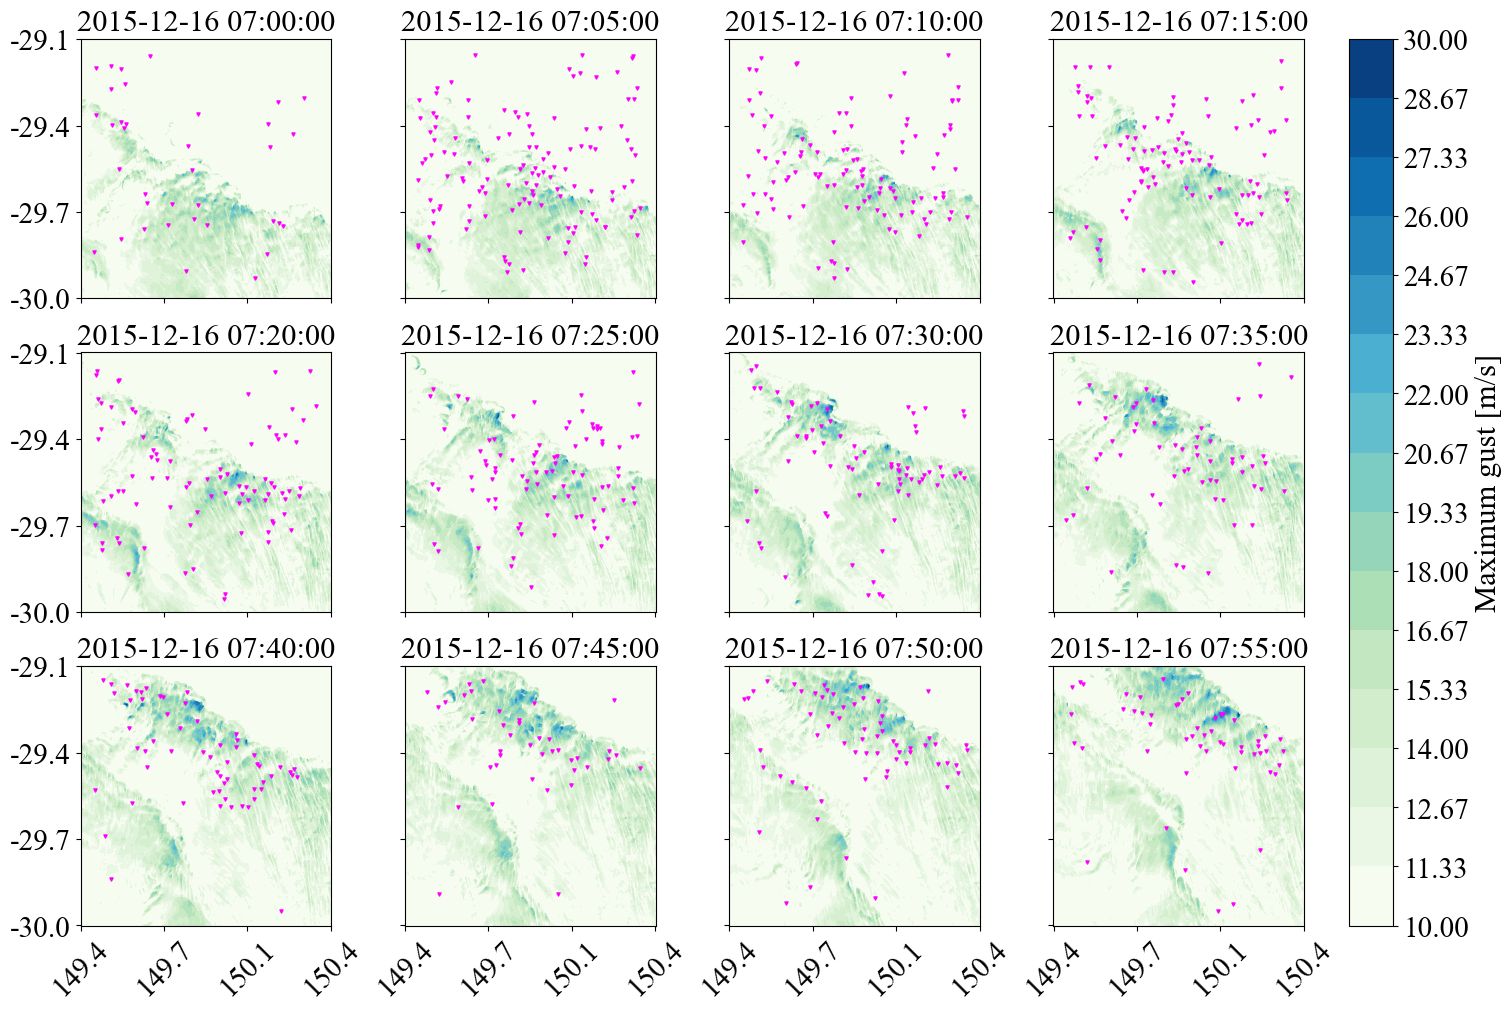

In [32]:
# Case 1
plot_2D_alltimes("CASE1", "WSMAX", cmap="GnBu",vmin=10, vmax=30, levels=16,
              cbar_kwargs={"label": "Maximum gust [m/s]", "shrink": 1.0}, name_fig = "FigureS9")

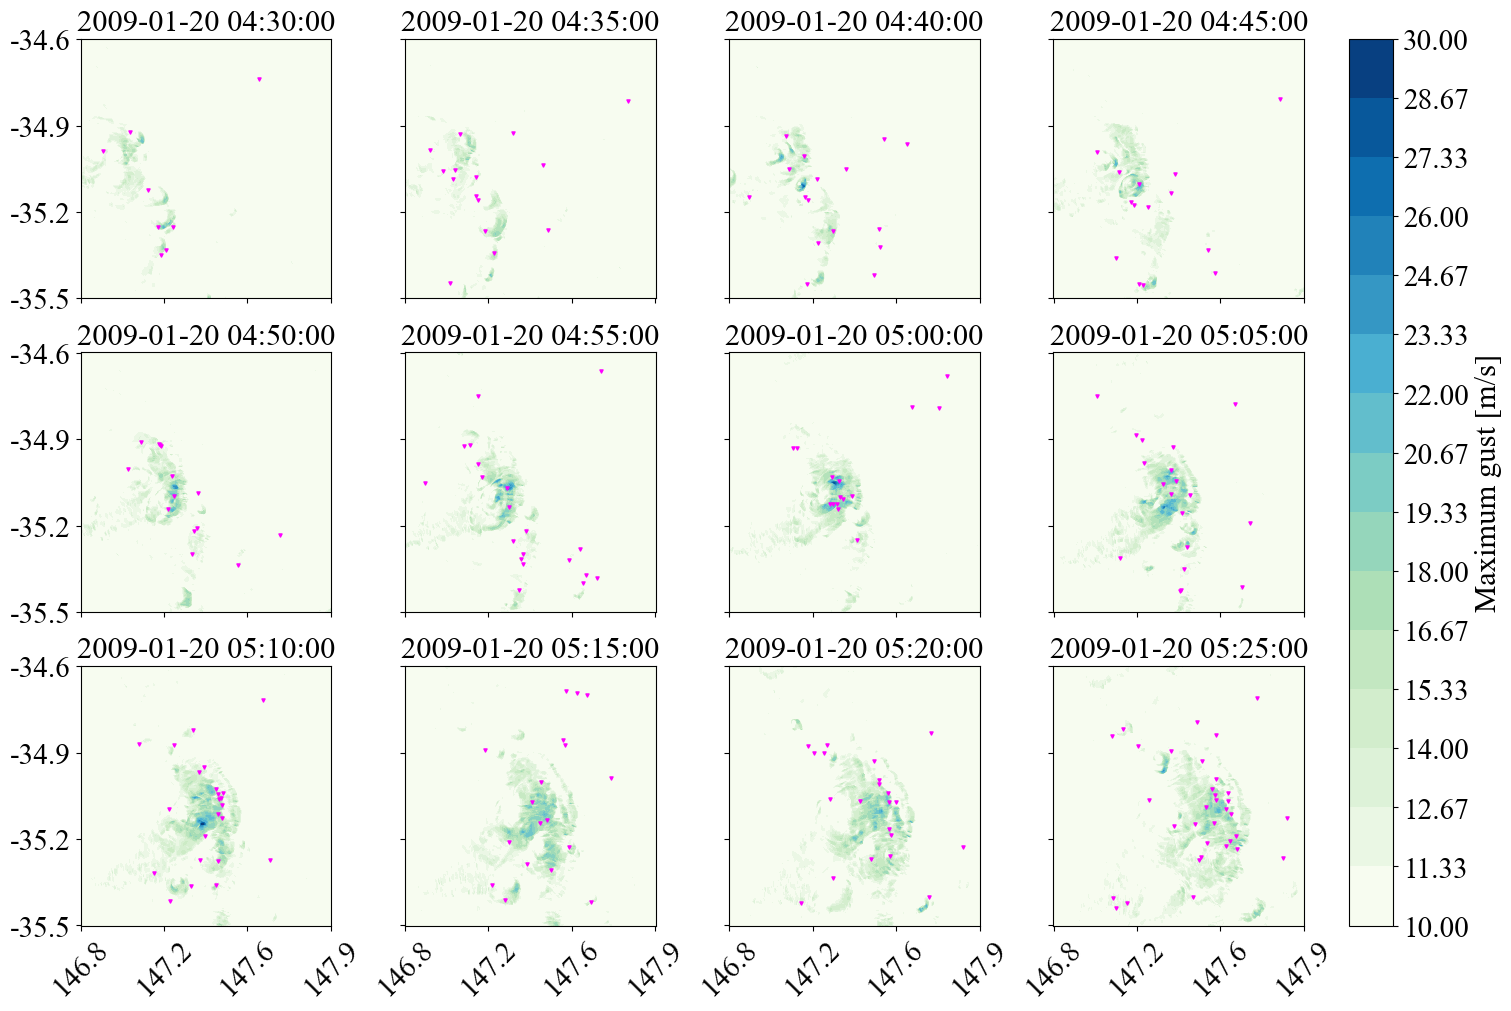

In [33]:
# Case 2
plot_2D_alltimes("CASE2_new", "WSMAX", cmap="GnBu",vmin=10, vmax=30, levels=16,
              cbar_kwargs={"label": "Maximum gust [m/s]", "shrink": 1.0}, name_fig = "FigureS10")

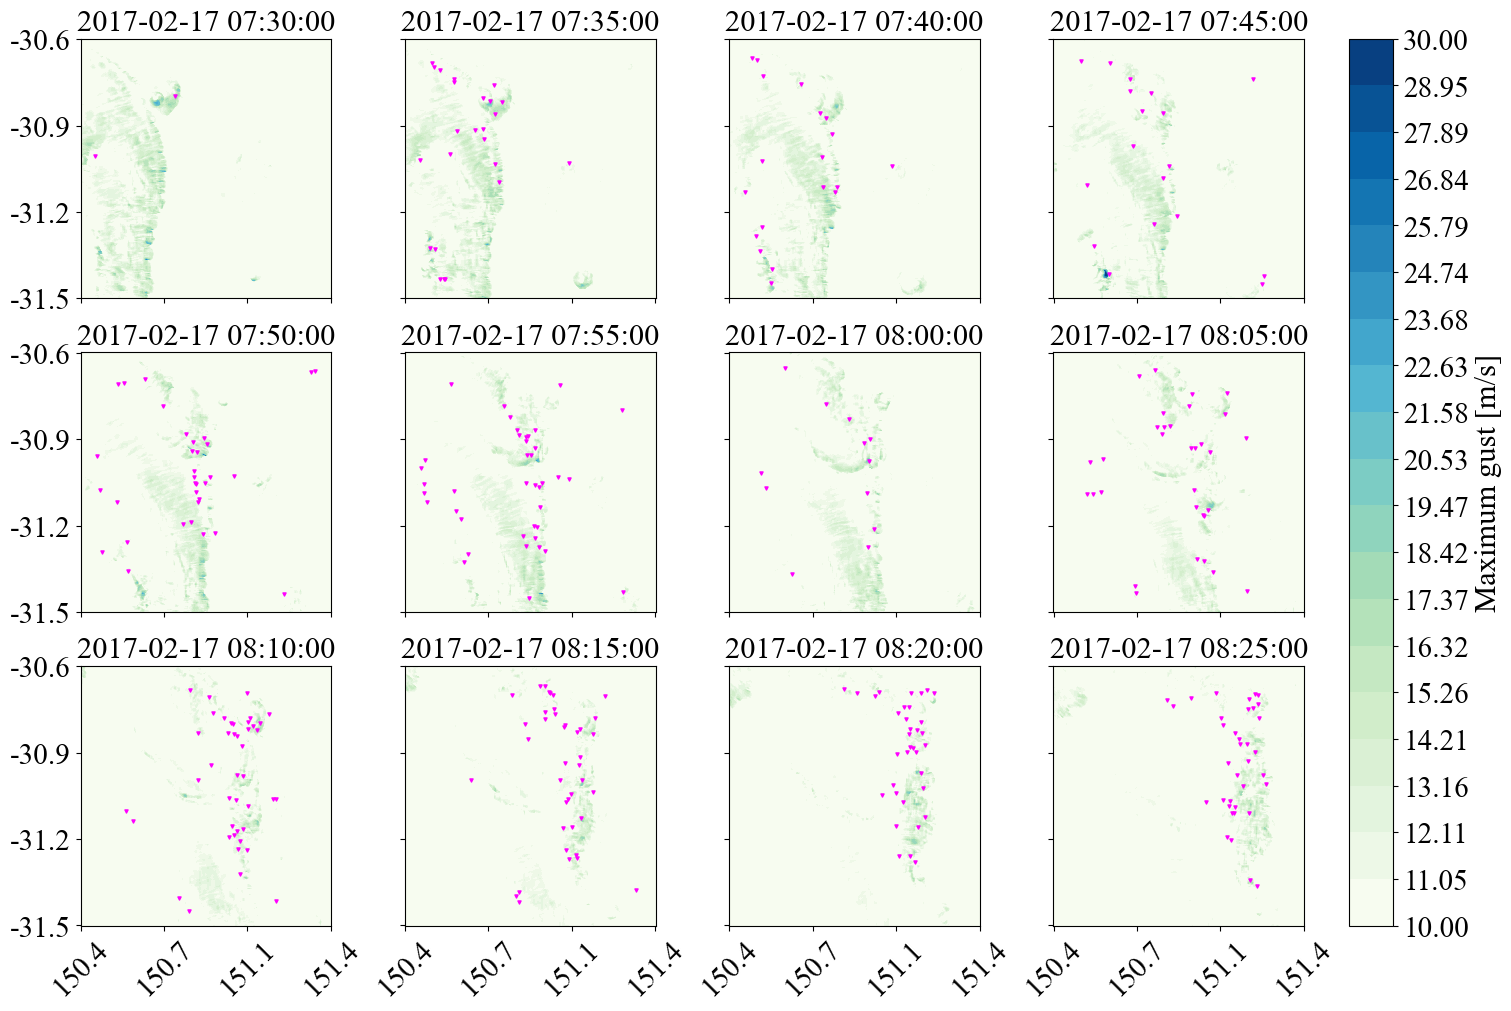

In [34]:
# Case 3
plot_2D_alltimes("CASE3_new", "WSMAX", cmap="GnBu",vmin=10, vmax=30, levels=20,
              cbar_kwargs={"label": "Maximum gust [m/s]", "shrink": 1.0}, name_fig = "FigureS11")